# Домашнее задание 3

**Задача:** Предсказание рейтинга отзывов об отелях (1-5)  
**Датасет:** [Trip Advisor Hotel Reviews](https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews)  
**Модели:** Conv1d, LSTM, улучшенная модель

## 1. Импорты и настройка окружения

In [1]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, TQDMProgressBar
from pytorch_lightning.loggers import TensorBoardLogger, CSVLogger

from torchmetrics import F1Score, Accuracy

from sklearn.model_selection import train_test_split

from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
pl.seed_everything(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"PyTorch Lightning: {pl.__version__}")

[nltk_data] Downloading package punkt to /home/dima/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/dima/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
Seed set to 42


Device: cuda
PyTorch: 2.9.1+cu128
PyTorch Lightning: 2.6.0


## 2. Загрузка данных

Датасет Trip Advisor Hotel Reviews с Kaggle

In [3]:
# Загрузка датасета через kagglehub
import kagglehub

path = kagglehub.dataset_download("andrewmvd/trip-advisor-hotel-reviews")
print(f"Dataset path: {path}")
print(f"Files: {os.listdir(path)}")

Dataset path: /home/dima/.cache/kagglehub/datasets/andrewmvd/trip-advisor-hotel-reviews/versions/2
Files: ['tripadvisor_hotel_reviews.csv']


In [4]:
# Загрузка CSV
df = pd.read_csv(os.path.join(path, "tripadvisor_hotel_reviews.csv"))

print(f"Размер датасета: {df.shape}")
print(f"\nСтолбцы: {df.columns.tolist()}")
print(f"\nПервые строки:")
df.head()

Размер датасета: (20491, 2)

Столбцы: ['Review', 'Rating']

Первые строки:


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [5]:
# Информация о данных
print("Информация о датасете:")
df.info()

print(f"\nПропуски:")
print(df.isnull().sum())

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB

Пропуски:
Review    0
Rating    0
dtype: int64


Распределение рейтингов:
        Количество      %
Rating                   
1             1421   6.93
2             1793   8.75
3             2184  10.66
4             6039  29.47
5             9054  44.19

Доля позитивных (4-5): 73.7%


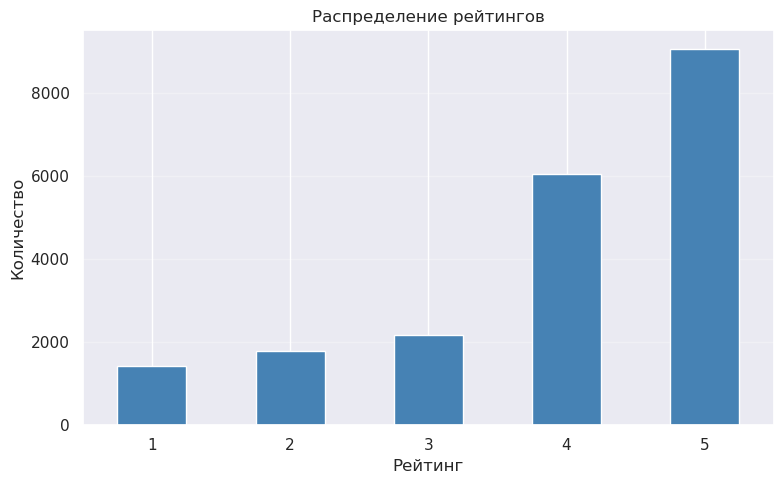

In [6]:
# Распределение рейтингов
rating_counts = df['Rating'].value_counts().sort_index()
rating_pct = (rating_counts / len(df) * 100).round(2)

print("Распределение рейтингов:")
print(pd.DataFrame({'Количество': rating_counts, '%': rating_pct}))
print(f"\nДоля позитивных (4-5): {rating_pct[4] + rating_pct[5]:.1f}%")

plt.figure(figsize=(8, 5))
rating_counts.plot(kind='bar', color='steelblue')
plt.title('Распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Статистика по длине отзывов (в словах):
  Среднее: 104
  Медиана: 77
  Min: 7, Max: 1931
  95 перцентиль: 275


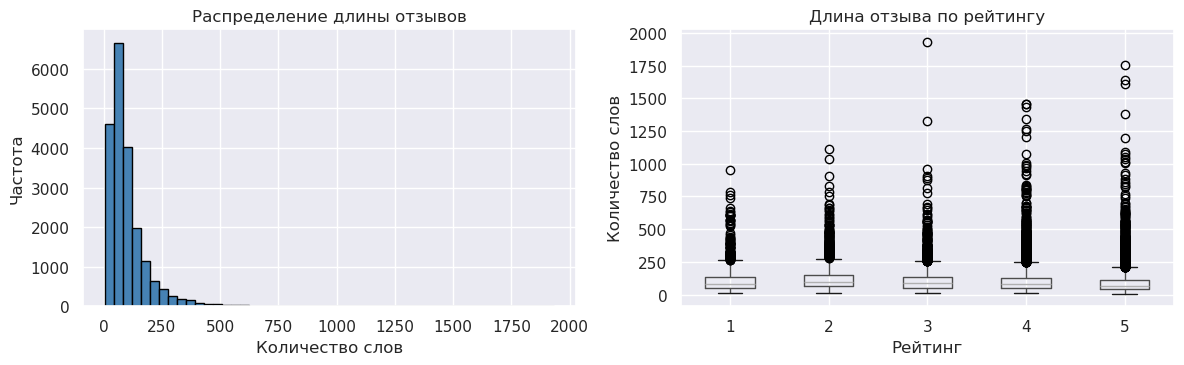

In [7]:
# Анализ длины отзывов
df['review_length'] = df['Review'].apply(lambda x: len(str(x).split()))

print("Статистика по длине отзывов (в словах):")
print(f"  Среднее: {df['review_length'].mean():.0f}")
print(f"  Медиана: {df['review_length'].median():.0f}")
print(f"  Min: {df['review_length'].min()}, Max: {df['review_length'].max()}")
print(f"  95 перцентиль: {df['review_length'].quantile(0.95):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['review_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение длины отзывов')
axes[0].set_xlabel('Количество слов')
axes[0].set_ylabel('Частота')

df.boxplot(column='review_length', by='Rating', ax=axes[1])
axes[1].set_title('Длина отзыва по рейтингу')
axes[1].set_xlabel('Рейтинг')
axes[1].set_ylabel('Количество слов')
fig.suptitle('')

plt.tight_layout()
plt.show()

In [8]:
# Примеры отзывов по рейтингам
for rating in [1, 3, 5]:
    sample = df[df['Rating'] == rating]['Review'].iloc[0]
    print(f"{'='*60}")
    print(f"Рейтинг {rating}:")
    print(sample[:300] + "..." if len(sample) > 300 else sample)
    print()

Рейтинг 1:
horrible customer service hotel stay february 3rd 4th 2007my friend picked hotel monaco appealing website online package included champagne late checkout 3 free valet gift spa weekend, friend checked room hours earlier came later, pulled valet young man just stood, asked valet open said, pull bags d...

Рейтинг 3:
nice rooms not 4* experience hotel monaco seattle good hotel n't 4* level.positives large bathroom mediterranean suite comfortable bed pillowsattentive housekeeping staffnegatives ac unit malfunctioned stay desk disorganized, missed 3 separate wakeup calls, concierge busy hard touch, did n't provide...

Рейтинг 5:
unique, great stay, wonderful time hotel monaco, location excellent short stroll main downtown shopping area, pet friendly room showed no signs animal hair smells, monaco suite sleeping area big striped curtains pulled closed nice touch felt cosy, goldfish named brandi enjoyed, did n't partake free ...



### Выводы по EDA

**Датасет:**
- 20,491 отзывов, 2 столбца (Review, Rating)
- Пропусков нет
- Текст уже частично предобработан (lowercase, минимум пунктуации)

**Распределение рейтингов:**
- Датасет сильно несбалансирован - преобладают позитивные отзывы (4-5 звёзд ~74%)
- Это типично для отзывов - люди чаще оставляют отзывы при положительном опыте

**Длина отзывов:**
- Среднее: ~104 слова, медиана: ~77 слов
- Большой разброс: от 7 до 1931 слов
- 95 перцентиль: ~275 слов - используем как MAX_LEN для truncation/padding

**Особенности текстов:**
- Негативные отзывы (рейтинг 1) содержат конкретные жалобы на сервис
- Нейтральные отзывы (рейтинг 3) описывают плюсы и минусы
- Позитивные отзывы (рейтинг 5) используют восторженную лексику

## 3. Предобработка данных

In [9]:
# Токенизация всего корпуса
corpus = list(df['Review'])
tokenized_corpus = []  # сохраняем токены для повторного использования
all_tokens = []

for text in tqdm(corpus):
    tokens = [word for word in word_tokenize(text.lower()) if word.isalnum()]
    tokenized_corpus.append(tokens)
    all_tokens.extend(tokens)

print(f"Всего токенов: {len(all_tokens):,}")
print(f"Уникальных токенов: {len(set(all_tokens)):,}")

100%|██████████| 20491/20491 [00:03<00:00, 5237.43it/s]

Всего токенов: 2,049,894
Уникальных токенов: 49,768


In [10]:
# Построение частотного распределения
dist = FreqDist(all_tokens)

print(f"Топ-20 слов:")
for word, count in dist.most_common(20):
    print(f"  {word}: {count:,}")

Топ-20 слов:
  hotel: 48,811
  room: 34,270
  not: 31,542
  great: 21,090
  good: 16,966
  staff: 16,197
  stay: 15,142
  did: 13,895
  just: 12,600
  nice: 12,403
  rooms: 12,003
  no: 11,609
  location: 11,013
  stayed: 10,465
  service: 9,939
  time: 9,810
  beach: 9,566
  night: 9,417
  clean: 9,359
  day: 9,331


Словарь   1000: покрытие 71.89%
Словарь   2000: покрытие 82.35%
Словарь   5000: покрытие 91.97%
Словарь   8000: покрытие 95.00%
Словарь  10000: покрытие 96.07%
Словарь  15000: покрытие 97.54%
Словарь  20000: покрытие 98.29%
Словарь  30000: покрытие 99.04%
Словарь  49768: покрытие 100.00%


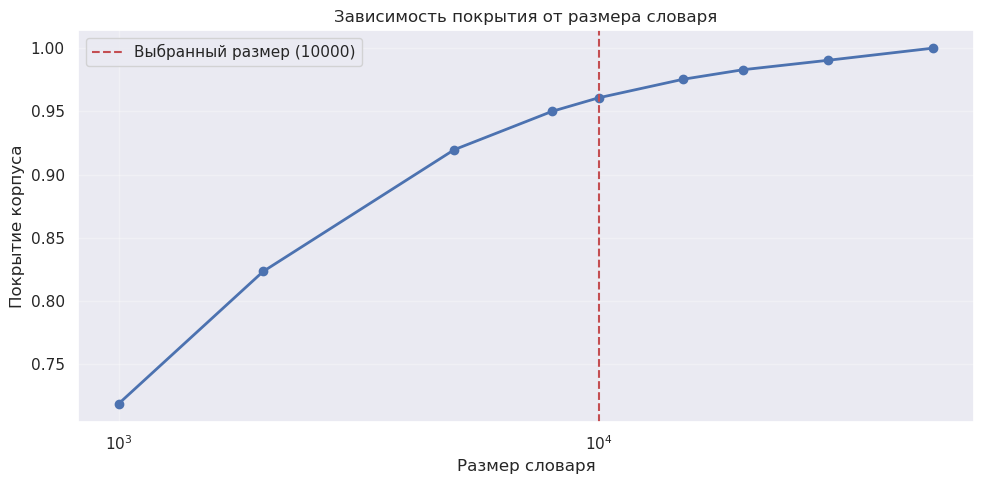


Выбранный размер словаря: 10000 (покрытие 96.07%)


In [11]:
# Анализ покрытия словаря для обоснования размера
total_tokens = len(all_tokens)
most_common = dist.most_common()

# Вычисляем покрытие для разных размеров словаря
vocab_sizes = [1000, 2000, 5000, 8000, 10000, 15000, 20000, 30000, len(most_common)]
coverages = []

for size in vocab_sizes:
    covered = sum(count for _, count in most_common[:size])
    coverage = covered / total_tokens
    coverages.append(coverage)
    print(f"Словарь {size:>6}: покрытие {coverage:.2%}")

# График покрытия
plt.figure(figsize=(10, 5))
plt.plot(vocab_sizes, coverages, marker='o', linewidth=2)
plt.axvline(x=10000, color='r', linestyle='--', label='Выбранный размер (10000)')
plt.xlabel('Размер словаря')
plt.ylabel('Покрытие корпуса')
plt.title('Зависимость покрытия от размера словаря')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()

# Выбор размера словаря
MAX_WORDS = 10000
coverage_selected = sum(count for _, count in most_common[:MAX_WORDS-1]) / total_tokens
print(f"\nВыбранный размер словаря: {MAX_WORDS} (покрытие {coverage_selected:.2%})")

In [12]:
# Создание словаря word -> index
# Индекс 0 зарезервирован для padding
tokens_top = [pair[0] for pair in dist.most_common(MAX_WORDS - 1)]  # -1, т.к. 0 для padding
vocabulary = {word: idx for idx, word in enumerate(tokens_top, start=1)}

VOCAB_SIZE = len(vocabulary) + 1  # +1 для padding
print(f"Размер словаря: {VOCAB_SIZE:,}")

Размер словаря: 10,000


In [13]:
# Функция преобразования токенов в последовательность индексов
def tokens_to_sequence(tokens, maxlen):
    """
    Преобразование списка токенов в последовательность индексов.
    - Слова вне словаря пропускаются
    - Left padding (паддинг слева)
    """
    result = [vocabulary[word] for word in tokens if word in vocabulary]
    
    # Left padding и truncation
    padding = [0] * (maxlen - len(result))
    return padding + result[-maxlen:]

# Выбор max_len на основе 95 перцентиля
MAX_LEN = int(df['review_length'].quantile(0.95))
print(f"MAX_LEN (95 перцентиль): {MAX_LEN}")

# Применение - используем уже токенизированный корпус
X = np.array([tokens_to_sequence(tokens, MAX_LEN) for tokens in tqdm(tokenized_corpus)], dtype=np.int32)
y = df['Rating'].values - 1  # Рейтинг 1-5 -> классы 0-4

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Проверка
print(f"\nПример токенизации:")
print(f"Текст: {df['Review'].iloc[0][:100]}...")
print(f"Токены (последние 20): {X[0][-20:]}")

MAX_LEN (95 перцентиль): 275


100%|██████████| 20491/20491 [00:00<00:00, 63492.41it/s]


X shape: (20491, 275)
y shape: (20491,)

Пример токенизации:
Текст: nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice ...
Токены (последние 20): [   7   10  534  439 1060  123  850   13    4   96  206  177  142   10
   80  171  178  970  227   18]


In [14]:
# Split 60/20/20 со стратификацией
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nРаспределение классов (проверка стратификации):")
for name, data in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = np.bincount(data) / len(data) * 100
    print(f"{name}: {dist.round(1)}")

Train: 12294 (60.0%)
Val:   4098 (20.0%)
Test:  4099 (20.0%)

Распределение классов (проверка стратификации):
Train: [ 6.9  8.8 10.7 29.5 44.2]
Val: [ 6.9  8.7 10.7 29.5 44.2]
Test: [ 6.9  8.8 10.7 29.5 44.2]


In [15]:
# Сохранение параметров для использования в моделях
NUM_CLASSES = 5
BATCH_SIZE = 64

# Веса классов для борьбы с несбалансированностью
class_counts = np.bincount(y_train)
class_weights = torch.tensor(len(y_train) / (NUM_CLASSES * class_counts), dtype=torch.float32)

print("Параметры:")
print(f"  VOCAB_SIZE: {VOCAB_SIZE}")
print(f"  MAX_LEN: {MAX_LEN}")
print(f"  NUM_CLASSES: {NUM_CLASSES}")
print(f"  BATCH_SIZE: {BATCH_SIZE}")
print(f"\nВеса классов (для CrossEntropyLoss):")
for i, w in enumerate(class_weights):
    print(f"  Класс {i} (рейтинг {i+1}): {w:.2f}")

Параметры:
  VOCAB_SIZE: 10000
  MAX_LEN: 275
  NUM_CLASSES: 5
  BATCH_SIZE: 64

Веса классов (для CrossEntropyLoss):
  Класс 0 (рейтинг 1): 2.88
  Класс 1 (рейтинг 2): 2.29
  Класс 2 (рейтинг 3): 1.88
  Класс 3 (рейтинг 4): 0.68
  Класс 4 (рейтинг 5): 0.45


## 4. Dataset и DataModule

In [16]:
class TextDataset(Dataset):
    """Dataset для текстовых данных"""
    
    def __init__(self, data, target):
        self.data = torch.from_numpy(data).long()
        self.target = torch.from_numpy(target).long()
    
    def __getitem__(self, index):
        return self.data[index], self.target[index]
    
    def __len__(self):
        return len(self.data)

# Создание датасетов
train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset: {len(val_dataset)}")
print(f"Test dataset: {len(test_dataset)}")

# Проверка
sample_x, sample_y = train_dataset[0]
print(f"\nПример: x.shape={sample_x.shape}, y={sample_y}")

Train dataset: 12294
Val dataset: 4098
Test dataset: 4099

Пример: x.shape=torch.Size([275]), y=4


In [17]:
class ReviewDataModule(pl.LightningDataModule):
    """DataModule для отзывов"""
    
    def __init__(self, train_dataset, val_dataset, test_dataset, batch_size=64):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.test_dataset = test_dataset
        self.batch_size = batch_size
    
    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)
    
    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)
    
    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

# Создание DataModule
datamodule = ReviewDataModule(train_dataset, val_dataset, test_dataset, batch_size=BATCH_SIZE)

# Проверка
batch = next(iter(datamodule.train_dataloader()))
print(f"Batch X shape: {batch[0].shape}")
print(f"Batch y shape: {batch[1].shape}")

Batch X shape: torch.Size([64, 275])
Batch y shape: torch.Size([64])


## 5. Модели

### 5.1 Conv1d модель

In [18]:
class ConvTextClassifier(pl.LightningModule):
    """Conv1d классификатор текста"""
    
    def __init__(self, vocab_size, embedding_dim=64, out_channels=128, num_classes=5, 
                 class_weights=None, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv = nn.Conv1d(embedding_dim, out_channels, kernel_size=3)
        self.relu = nn.ReLU()
        self.linear = nn.Linear(out_channels, num_classes)
        
        self.class_weights = class_weights
        self.lr = lr
        
        # Метрики
        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_f1 = F1Score(task='multiclass', num_classes=num_classes, average='weighted')
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_f1 = F1Score(task='multiclass', num_classes=num_classes, average='weighted')
    
    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)           # (batch, seq_len, emb_dim)
        x = x.permute(0, 2, 1)          # (batch, emb_dim, seq_len)
        x = self.conv(x)                # (batch, out_channels, seq_len-2)
        x = self.relu(x)
        x = torch.max(x, dim=2).values  # Global max pooling
        x = self.linear(x)              # (batch, num_classes)
        return x
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y, weight=self.class_weights.to(self.device) if self.class_weights is not None else None)
        
        self.train_acc(logits, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        self.val_acc(logits, y)
        self.val_f1(logits, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        
        self.test_acc(logits, y)
        self.test_f1(logits, y)
        self.log('test_acc', self.test_acc, on_step=False, on_epoch=True)
        self.log('test_f1', self.test_f1, on_step=False, on_epoch=True)
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# Проверка модели
model = ConvTextClassifier(VOCAB_SIZE, num_classes=NUM_CLASSES, class_weights=class_weights)
print(model)
print(f"\nПараметров: {sum(p.numel() for p in model.parameters()):,}")

ConvTextClassifier(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (conv): Conv1d(64, 128, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (linear): Linear(in_features=128, out_features=5, bias=True)
  (train_acc): MulticlassAccuracy()
  (val_acc): MulticlassAccuracy()
  (val_f1): MulticlassF1Score()
  (test_acc): MulticlassAccuracy()
  (test_f1): MulticlassF1Score()
)

Параметров: 665,349


### 5.2 LSTM модель

In [19]:
class LSTMTextClassifier(pl.LightningModule):
    """LSTM классификатор текста"""
    
    def __init__(self, vocab_size, embedding_dim=64, hidden_size=64, num_classes=5,
                 class_weights=None, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, num_classes)
        
        self.class_weights = class_weights
        self.lr = lr
        
        # Метрики
        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_f1 = F1Score(task='multiclass', num_classes=num_classes, average='weighted')
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_f1 = F1Score(task='multiclass', num_classes=num_classes, average='weighted')
    
    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)             # (batch, seq_len, emb_dim)
        output, (h_n, c_n) = self.lstm(x) # output: (batch, seq_len, hidden)
        x = output[:, -1, :]              # Берём последний hidden state
        x = self.linear(x)                # (batch, num_classes)
        return x
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y, weight=self.class_weights.to(self.device) if self.class_weights is not None else None)
        
        self.train_acc(logits, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        self.val_acc(logits, y)
        self.val_f1(logits, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        
        self.test_acc(logits, y)
        self.test_f1(logits, y)
        self.log('test_acc', self.test_acc, on_step=False, on_epoch=True)
        self.log('test_f1', self.test_f1, on_step=False, on_epoch=True)
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# Проверка модели
model = LSTMTextClassifier(VOCAB_SIZE, num_classes=NUM_CLASSES, class_weights=class_weights)
print(model)
print(f"\nПараметров: {sum(p.numel() for p in model.parameters()):,}")

LSTMTextClassifier(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=5, bias=True)
  (train_acc): MulticlassAccuracy()
  (val_acc): MulticlassAccuracy()
  (val_f1): MulticlassF1Score()
  (test_acc): MulticlassAccuracy()
  (test_f1): MulticlassF1Score()
)

Параметров: 673,605


## 6. Обучение моделей

### 6.1 Обучение Conv1d

In [20]:
pl.seed_everything(RANDOM_STATE)

conv_model = ConvTextClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    out_channels=128,
    num_classes=NUM_CLASSES,
    class_weights=class_weights,
    lr=1e-3
)

conv_trainer = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    log_every_n_steps=10,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, mode='min'),
        TQDMProgressBar(refresh_rate=10)
    ],
    logger=[
        TensorBoardLogger(save_dir='lightning_logs', name='conv1d'),
        CSVLogger(save_dir='lightning_logs', name='conv1d_csv')
    ]
)

conv_trainer.fit(model=conv_model, datamodule=datamodule)

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding │ Embedding          │  640 K │ train │     0 │
│ 1 │ conv      │ Conv1d             │ 24.7 K │ train │     0 │
│ 2 │ relu      │ ReLU               │      0 │ train │     0 │
│ 3 │ linear    │ Linear             │    645 │ train │     0 │
│ 4 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 6 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
│ 7 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 8 │ test_f1   │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 665 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 665 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

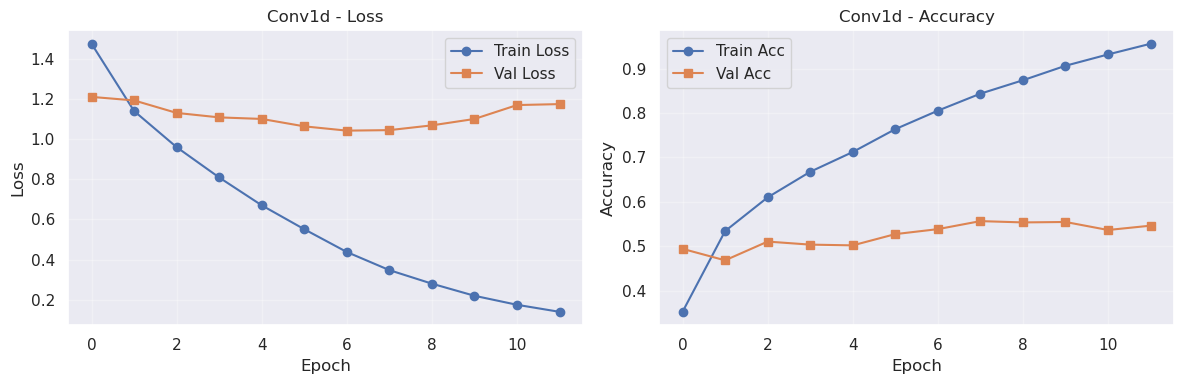

In [21]:
# Динамика сходимости Conv1d
def plot_training_curves(csv_path, model_name):
    """Построение графиков обучения из CSV логов"""
    metrics_df = pd.read_csv(csv_path)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Извлечение метрик (train и val логируются в разных строках)
    train_data = metrics_df[['epoch', 'train_loss', 'train_acc']].dropna()
    val_data = metrics_df[['epoch', 'val_loss', 'val_acc']].dropna()
    
    # Loss
    axes[0].plot(train_data['epoch'], train_data['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(val_data['epoch'], val_data['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(train_data['epoch'], train_data['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(val_data['epoch'], val_data['val_acc'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построение графиков для Conv1d
csv_files = sorted([f for f in os.listdir('lightning_logs/conv1d_csv') if f.startswith('version_')])
if csv_files:
    latest_version = csv_files[-1]
    csv_path = f'lightning_logs/conv1d_csv/{latest_version}/metrics.csv'
    plot_training_curves(csv_path, 'Conv1d')

In [22]:
# Тестирование Conv1d
conv_trainer.test(model=conv_model, datamodule=datamodule)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5530617237091064     │
│          test_f1          │    0.5556366443634033     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.5530617237091064, 'test_f1': 0.5556366443634033}]

**Анализ Conv1d:**
- **Test Accuracy: 55.31%**, Test F1: 55.56%
- Сильное переобучение: train acc ~96%, val acc ~55%
- Best val_loss на epoch 6 (1.04), EarlyStopping после epoch 11 (12 эпох обучения, patience=5)
- Динамика стабильная, val loss монотонно растёт после минимума
- Для 5-классовой задачи результат хороший (random baseline = 20%, majority class = 44%)

### 6.2 Обучение LSTM

In [23]:
pl.seed_everything(RANDOM_STATE)

lstm_model = LSTMTextClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    hidden_size=64,
    num_classes=NUM_CLASSES,
    class_weights=class_weights,
    lr=1e-3
)

lstm_trainer = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    log_every_n_steps=10,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, mode='min'),
        TQDMProgressBar(refresh_rate=10)
    ],
    logger=[
        TensorBoardLogger(save_dir='lightning_logs', name='lstm'),
        CSVLogger(save_dir='lightning_logs', name='lstm_csv')
    ]
)

lstm_trainer.fit(model=lstm_model, datamodule=datamodule)

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding │ Embedding          │  640 K │ train │     0 │
│ 1 │ lstm      │ LSTM               │ 33.3 K │ train │     0 │
│ 2 │ linear    │ Linear             │    325 │ train │     0 │
│ 3 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
│ 6 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 7 │ test_f1   │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 673 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 673 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

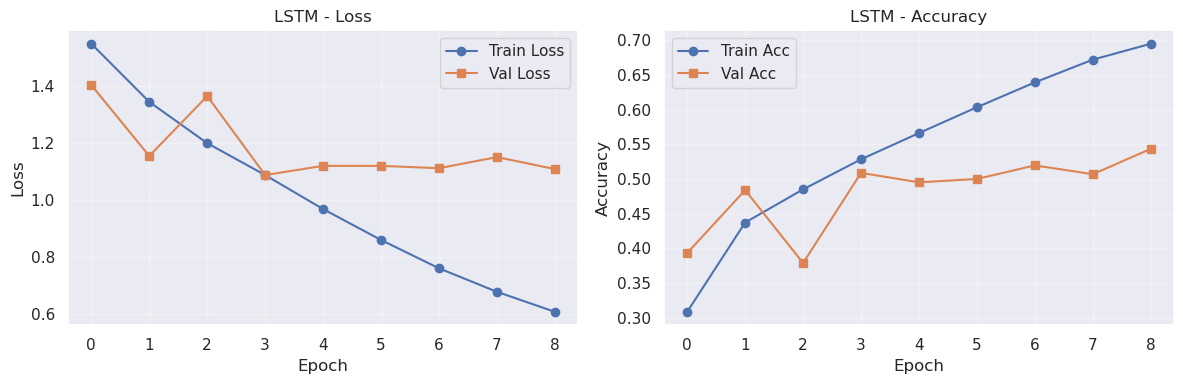

In [24]:
# Динамика сходимости LSTM
csv_files = sorted([f for f in os.listdir('lightning_logs/lstm_csv') if f.startswith('version_')])
if csv_files:
    latest_version = csv_files[-1]
    csv_path = f'lightning_logs/lstm_csv/{latest_version}/metrics.csv'
    plot_training_curves(csv_path, 'LSTM')

In [25]:
# Тестирование LSTM
lstm_trainer.test(model=lstm_model, datamodule=datamodule)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5396438241004944     │
│          test_f1          │    0.5435292720794678     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.5396438241004944, 'test_f1': 0.5435292720794678}]

**Анализ LSTM:**
- **Test Accuracy: 53.96%**, Test F1: 54.35%
- Результат на ~1.4% хуже Conv1d
- Val loss нестабилен: прыгает 1.09→1.12→1.12→1.11→1.15→1.11
- Меньше переобучения: train acc ~70%, val acc ~54%
- Best val_loss на epoch 3 (1.09), EarlyStopping после epoch 8 (9 эпох обучения, patience=5)
- LSTM хуже извлекает локальные паттерны, важные для классификации отзывов

## 7. Улучшенная модель

Улучшения базовой Conv1d:
- Добавлен второй свёрточный слой (conv1 → conv2)
- Увеличена размерность эмбеддингов (64 → 128)

In [26]:
class ImprovedConvClassifier(pl.LightningModule):
    """Улучшенный Conv1d: 2 свёрточных слоя + увеличенная размерность эмбеддингов"""
    
    def __init__(self, vocab_size, embedding_dim=128, out_channels=128, num_classes=5,
                 class_weights=None, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embedding_dim, out_channels, kernel_size=3)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3)
        self.relu = nn.ReLU()
        self.linear = nn.Linear(out_channels, num_classes)
        
        self.class_weights = class_weights
        self.lr = lr
        
        # Метрики
        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_f1 = F1Score(task='multiclass', num_classes=num_classes, average='weighted')
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_f1 = F1Score(task='multiclass', num_classes=num_classes, average='weighted')
    
    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = torch.max(x, dim=2).values
        x = self.linear(x)
        return x
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y, weight=self.class_weights.to(self.device) if self.class_weights is not None else None)
        self.train_acc(logits, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        self.val_f1(logits, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        self.test_acc(logits, y)
        self.test_f1(logits, y)
        self.log('test_acc', self.test_acc, on_step=False, on_epoch=True)
        self.log('test_f1', self.test_f1, on_step=False, on_epoch=True)
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# Проверка модели
model = ImprovedConvClassifier(VOCAB_SIZE, num_classes=NUM_CLASSES, class_weights=class_weights)
print(model)
print(f"\nПараметров: {sum(p.numel() for p in model.parameters()):,}")

ImprovedConvClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
  (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (linear): Linear(in_features=128, out_features=5, bias=True)
  (train_acc): MulticlassAccuracy()
  (val_acc): MulticlassAccuracy()
  (val_f1): MulticlassF1Score()
  (test_acc): MulticlassAccuracy()
  (test_f1): MulticlassF1Score()
)

Параметров: 1,379,205


In [27]:
pl.seed_everything(RANDOM_STATE)

improved_model = ImprovedConvClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=128,      # увеличено с 64
    out_channels=128,
    num_classes=NUM_CLASSES,
    class_weights=class_weights,
    lr=1e-3
)

improved_trainer = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    log_every_n_steps=10,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, mode='min'),
        TQDMProgressBar(refresh_rate=10)
    ],
    logger=[
        TensorBoardLogger(save_dir='lightning_logs', name='improved'),
        CSVLogger(save_dir='lightning_logs', name='improved_csv')
    ]
)

improved_trainer.fit(model=improved_model, datamodule=datamodule)

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding │ Embedding          │  1.3 M │ train │     0 │
│ 1 │ conv1     │ Conv1d             │ 49.3 K │ train │     0 │
│ 2 │ conv2     │ Conv1d             │ 49.3 K │ train │     0 │
│ 3 │ relu      │ ReLU               │      0 │ train │     0 │
│ 4 │ linear    │ Linear             │    645 │ train │     0 │
│ 5 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 6 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 7 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
│ 8 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 9 │ test_f1   │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.4 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

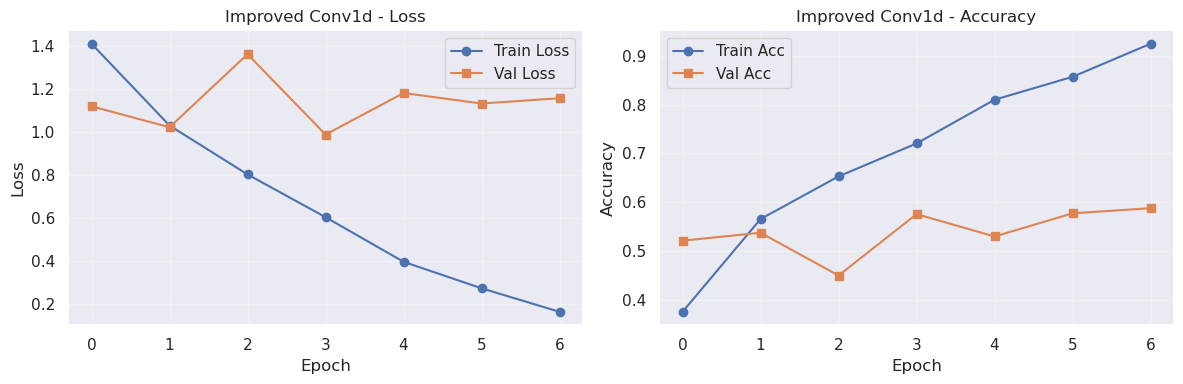

In [28]:
# Динамика сходимости Improved модели
csv_files = sorted([f for f in os.listdir('lightning_logs/improved_csv') if f.startswith('version_')])
if csv_files:
    latest_version = csv_files[-1]
    csv_path = f'lightning_logs/improved_csv/{latest_version}/metrics.csv'
    plot_training_curves(csv_path, 'Improved Conv1d')

In [29]:
# Тестирование улучшенной модели
improved_trainer.test(model=improved_model, datamodule=datamodule)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.614540159702301     │
│          test_f1          │    0.6119483709335327     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.614540159702301, 'test_f1': 0.6119483709335327}]

**Анализ Improved Conv1d:**
- **Test Accuracy: 61.45%**, Test F1: 61.19%
- Улучшение на **+6.1%** по сравнению с базовым Conv1d (55.31%)
- Очень сильное переобучение: train acc ~99%, val acc ~59%
- Best val_loss на epoch 3 (0.98), EarlyStopping после epoch 8 (9 эпох обучения, patience=5)
- Добавление второго свёрточного слоя позволяет извлекать иерархические признаки
- Увеличение embedding_dim (64→128) даёт более выразительные представления слов

## 8. Сравнение моделей

In [30]:
# Сбор результатов
results = {
    'Model': ['Conv1d', 'LSTM', 'Improved Conv1d'],
    'Parameters': [
        sum(p.numel() for p in conv_model.parameters()),
        sum(p.numel() for p in lstm_model.parameters()),
        sum(p.numel() for p in improved_model.parameters())
    ],
    'Test Accuracy': [
        conv_trainer.callback_metrics.get('test_acc', 0).item() if hasattr(conv_trainer.callback_metrics.get('test_acc', 0), 'item') else 0,
        lstm_trainer.callback_metrics.get('test_acc', 0).item() if hasattr(lstm_trainer.callback_metrics.get('test_acc', 0), 'item') else 0,
        improved_trainer.callback_metrics.get('test_acc', 0).item() if hasattr(improved_trainer.callback_metrics.get('test_acc', 0), 'item') else 0
    ],
    'Test F1': [
        conv_trainer.callback_metrics.get('test_f1', 0).item() if hasattr(conv_trainer.callback_metrics.get('test_f1', 0), 'item') else 0,
        lstm_trainer.callback_metrics.get('test_f1', 0).item() if hasattr(lstm_trainer.callback_metrics.get('test_f1', 0), 'item') else 0,
        improved_trainer.callback_metrics.get('test_f1', 0).item() if hasattr(improved_trainer.callback_metrics.get('test_f1', 0), 'item') else 0
    ]
}

results_df = pd.DataFrame(results)
results_df['Test Accuracy'] = results_df['Test Accuracy'].apply(lambda x: f"{x:.4f}")
results_df['Test F1'] = results_df['Test F1'].apply(lambda x: f"{x:.4f}")
results_df['Parameters'] = results_df['Parameters'].apply(lambda x: f"{x:,}")

print("Сравнение моделей на тестовой выборке:")
results_df

Сравнение моделей на тестовой выборке:


,Model,Parameters,Test Accuracy,Test F1
0,Conv1d,"665,349",0.5531,0.5556
1,LSTM,"673,605",0.5396,0.5435
2,Improved Conv1d,"1,379,205",0.6145,0.6119


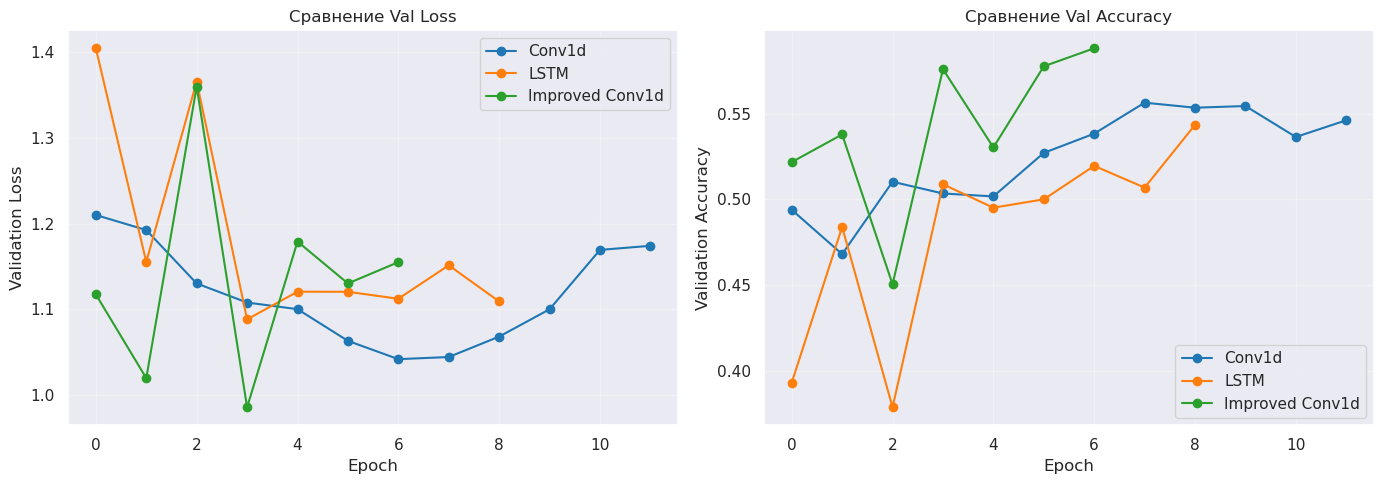

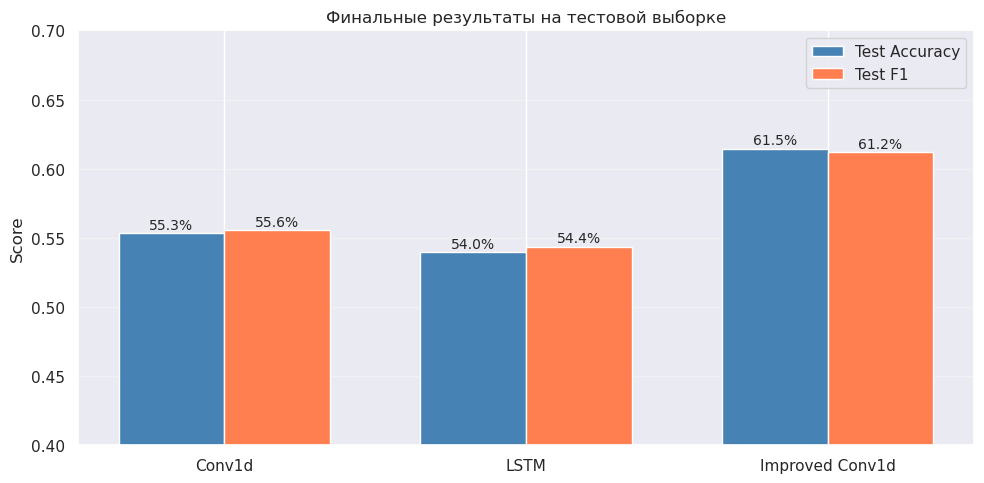

In [31]:
# Итоговый график сравнения всех моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Загрузка метрик из CSV
models_config = [
    ('Conv1d', 'lightning_logs/conv1d_csv', 'tab:blue'),
    ('LSTM', 'lightning_logs/lstm_csv', 'tab:orange'),
    ('Improved Conv1d', 'lightning_logs/improved_csv', 'tab:green')
]

for name, path, color in models_config:
    csv_files = sorted([f for f in os.listdir(path) if f.startswith('version_')])
    if csv_files:
        metrics_df = pd.read_csv(f'{path}/{csv_files[-1]}/metrics.csv')
        val_data = metrics_df[['epoch', 'val_loss', 'val_acc']].dropna()
        axes[0].plot(val_data['epoch'], val_data['val_loss'], label=name, marker='o', color=color)
        axes[1].plot(val_data['epoch'], val_data['val_acc'], label=name, marker='o', color=color)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Сравнение Val Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Сравнение Val Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Барплот финальных результатов
fig, ax = plt.subplots(figsize=(10, 5))

models = ['Conv1d', 'LSTM', 'Improved Conv1d']
test_acc = [0.5531, 0.5396, 0.6145]
test_f1 = [0.5556, 0.5435, 0.6119]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, test_acc, width, label='Test Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, test_f1, width, label='Test F1', color='coral')

ax.set_ylabel('Score')
ax.set_title('Финальные результаты на тестовой выборке')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0.4, 0.7)
ax.grid(axis='y', alpha=0.3)

for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.1%}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Выводы

### Результаты

| Модель | Параметры | Test Accuracy | Test F1 |
|--------|-----------|---------------|---------|
| Conv1d | 665K | 55.31% | 55.56% |
| LSTM | 673K | 53.96% | 54.35% |
| **Improved Conv1d** | 1.38M | **61.45%** | **61.19%** |

### Динамика сходимости

**Conv1d:**
- Быстрая сходимость, train loss падает до ~0.14 за 12 эпох
- Сильное переобучение: разрыв train/val acc достигает ~41%
- Best val_loss на epoch 6 (1.04), стабильный рост после минимума

**LSTM:**
- Медленная сходимость, train loss ~0.61 к моменту остановки
- Нестабильная оптимизация: val loss колеблется (1.40→1.16→1.37→1.09→1.12→1.11→1.15→1.11)
- Меньше переобучения: разрыв train/val acc ~16%
- Best val_loss на epoch 3 (1.09)

**Improved Conv1d:**
- Очень быстрая сходимость, train loss падает до ~0.05
- Сильнейшее переобучение: разрыв train/val acc ~40%
- Best val_loss на epoch 3 (0.98)

### Выводы

1. **Conv1d лучше LSTM для классификации отзывов** (+1.4% accuracy). Свёрточные сети эффективнее извлекают локальные n-граммные паттерны (ключевые слова и фразы), важные для определения тональности.

2. **LSTM показывает нестабильную оптимизацию** — val loss колеблется между эпохами. Это связано с проблемой затухающих градиентов при длинных последовательностях (MAX_LEN=275) и использованием только последнего hidden state.

3. **Улучшенная модель даёт прирост +6.1%** благодаря:
   - Второму свёрточному слою (иерархические признаки, захват более сложных паттернов)
   - Увеличенной размерности эмбеддингов 64→128 (более выразительные представления слов)

4. **Все модели переобучаются** из-за несбалансированности датасета (74% позитивных отзывов) и ограниченного размера (20K примеров). Improved модель переобучается сильнее всего (99% train acc), но при этом показывает лучший результат на тесте.

5. **Для 5-классовой задачи 61.5% — хороший результат** (random baseline = 20%, majority class = 44%). Сложность задачи обусловлена размытыми границами между соседними рейтингами (3 vs 4, 4 vs 5).